# Tree normalising flows for phylogenetic VI

A **tree normalising flow** puts a flexible, tree-structured distribution on the
unconstrained node-height coordinates that sit underneath treeflow's node-height
ratio transform. Each layer is a *traversal sandwich*:

1. a **postorder** (tip-to-root) affine map -- each node reads its children's outputs;
2. a **learnable elementwise nonlinearity** -- shared across the tree with
   per-node affine conditioning (no traversal). It is pluggable: a monotone
   rational-quadratic spline (the default), `sinh_arcsinh`, or none at all
   (`"affine"`), which reduces the flow to a Gaussian with tree-structured
   covariance;
3. a **preorder** (root-to-tip) affine map -- each node reads its parent's output.

Up-then-down is the collect/distribute schedule of belief propagation, and it is
what makes a *single* layer couple every pair of nodes: node `i` ends up
depending on the descendants of its ancestors, i.e. on everything. The flow is
optionally **conditional** -- on the other model parameters (clock rate,
population size, substitution parameters) and on per-branch parameters -- so the
tree block can depend on the rest of the model.

Both affine maps are triangular in their own traversal order, so the
log-det-Jacobian is `sum_i log scale[i]` and the inverse is a gather; the forward
sweeps run either through the pure-TensorFlow traversal primitives or through
the native C++ ops.

This notebook compares the flow with the **root full-rank** approximation
already in treeflow (`get_fixed_topology_root_full_rank_approximation`: one
full-rank Gaussian block over the non-tree parameters plus the root height, and
mean-field over the remaining ratios) on a **simulated dataset**, in two
studies:

* **Study 1 -- heights only.** Every non-tree parameter is fixed, so the target
  is the posterior over node heights alone. This isolates what the flow buys
  *within* the tree.
* **Study 2 -- full model.** An inverse autoregressive flow on the other
  parameters and the tree flow on the node heights, conditioned on those
  parameters.

Both studies reuse treeflow's existing model definitions (`PhyloModel`, the HKY +
discretised-gamma likelihood, the constant coalescent) and its native likelihood.

Simulating the data (with `experiments/benchmarks/simulate.py`, the same
simulator the benchmark pipeline uses) buys two things a real alignment cannot.
The dataset is small enough -- a dozen taxa by default -- that the random-walk
reference chain genuinely mixes, so the accuracy comparison rests on a reference
that passes its own diagnostics; and the parameter values that generated the data
are known, so the approximations can be checked against the truth as well as
against each other. `TREEFLOW_TREE_FLOW_TAXON_COUNT` and
`..._SITE_COUNT` (or the `--taxa` / `--sites` flags of
`experiments/run_tree_flow_experiment.py`) scale it up.

## Setup

In [1]:
from functools import partial
from types import SimpleNamespace

import numpy as np
import yaml
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from tqdm import tqdm

tf.get_logger().setLevel("ERROR")
tfd = tfp.distributions

from treeflow import PhyloModel, convert_tree_to_tensor
from treeflow.model.phylo_model import phylo_model_to_joint_distribution

# The simulator that experiments/benchmarks uses, so the data this notebook
# judges approximations on is generated by the same code path that scores
# likelihoods (importable because the notebook's own directory is the kernel's
# working directory).
from benchmarks.simulate import (
    simulate_alignment,
    simulate_coalescent_tree,
    simulate_sampling_times,
)
from treeflow.distributions import (
    DiscretizedDistribution,
    DiscreteParameterMixture,
    LeafCTMC,
)
from treeflow.distributions.tree import ConstantCoalescent
from treeflow.evolution.substitution import HKY, get_transition_probabilities_tree
from treeflow.model.approximation import (
    get_fixed_topology_mean_field_approximation,
    get_fixed_topology_full_rank_approximation,
    get_fixed_topology_root_full_rank_approximation,
    get_fixed_topology_tree_flow_approximation,
)
from treeflow.vi import (
    fit_fixed_topology_variational_approximation,
    RobustOptimizer,
    RelativeLossNotDecreasing,
)
from treeflow.mcmc import (
    fit_fixed_topology_random_walk_metropolis,
    check_effective_sample_size,
    effective_sample_size_summary,
)

I0000 00:00:1785750385.567301   18239 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785750385.569743   18239 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785750385.699651   18239 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785750388.170132   18239 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785750388.170927   18239 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Silencing TensorFlow...


In [2]:
import os

_env = lambda name, default: type(default)(os.environ.get(name, default))

# Every size is overridable from the environment, so the same notebook serves a
# quick smoke run and a full one. `experiments/run_tree_flow_experiment.py`
# sets these from command-line flags.
# Optimisation. 60k steps at 1e-3 is the budget these models are known to need
# to converge; the convergence criterion below usually stops a fit well before
# it, so NUM_STEPS is a ceiling rather than a target.
NUM_STEPS = _env("TREEFLOW_TREE_FLOW_NUM_STEPS", 60_000)
LEARNING_RATE = _env("TREEFLOW_TREE_FLOW_LEARNING_RATE", 0.001)

# Early stopping is OFF by default, and deliberately so. RelativeLossNotDecreasing
# (the criterion advi_iaf.ipynb uses) stops when EWMA(per-step ELBO decrease) /
# |ELBO| falls below a tolerance -- but on this problem it fired within ~50 steps
# of whatever floor it was given, at both 5,000 and 20,000 steps and at
# tolerances of 1e-6 and 1e-7. A criterion that reports "converged" wherever you
# put its floor is measuring the floor, not convergence, so the fits below simply
# run the full NUM_STEPS. Set TREEFLOW_TREE_FLOW_CONVERGENCE_MIN_STEPS (and
# optionally ..._CONVERGENCE_RTOL) to switch it back on.
CONVERGENCE_MIN_STEPS = _env("TREEFLOW_TREE_FLOW_CONVERGENCE_MIN_STEPS", 0)
CONVERGENCE_RTOL = _env("TREEFLOW_TREE_FLOW_CONVERGENCE_RTOL", 1e-7)
CONVERGENCE_WINDOW = 1_000
CONVERGENCE_MIN_CONSECUTIVE = 3

# Seconds between progress-bar refreshes. Each refresh is a line recorded in the
# executed notebook, so a long run with a chatty bar buries the output it should
# be showing; 30 seconds keeps a fit's bar to a few dozen lines.
PROGRESS_INTERVAL = _env("TREEFLOW_TREE_FLOW_PROGRESS_INTERVAL", 30.0)
PROGRESS_STEP = 100  # optimisation steps between progress-bar updates
SAMPLE_SIZE = _env("TREEFLOW_TREE_FLOW_SAMPLE_SIZE", 4)   # MC samples per ELBO gradient
ELBO_SAMPLES = _env("TREEFLOW_TREE_FLOW_ELBO_SAMPLES", 512)  # for the final ELBO estimate
ELBO_CHUNK = 32                                           # ELBO samples per likelihood call
N_SAMPLES = _env("TREEFLOW_TREE_FLOW_N_SAMPLES", 4_000)   # posterior samples per fit

# Reference posterior (random-walk Metropolis-Hastings).
MCMC_RESULTS = _env("TREEFLOW_TREE_FLOW_MCMC_RESULTS", 20_000)
MCMC_BURNIN = _env("TREEFLOW_TREE_FLOW_MCMC_BURNIN", 10_000)
MCMC_CHAINS = _env("TREEFLOW_TREE_FLOW_MCMC_CHAINS", 4)
MCMC_THIN = _env("TREEFLOW_TREE_FLOW_MCMC_THIN", 5)        # steps run per sample kept
MCMC_MIN_ESS = _env("TREEFLOW_TREE_FLOW_MCMC_MIN_ESS", 200.0)

# Simulated dataset.
TAXON_COUNT = _env("TREEFLOW_TREE_FLOW_TAXON_COUNT", 20)
SITE_COUNT = _env("TREEFLOW_TREE_FLOW_SITE_COUNT", 500)
SAMPLING_WINDOW = _env("TREEFLOW_TREE_FLOW_SAMPLING_WINDOW", 5.0)
DATA_SEED = _env("TREEFLOW_TREE_FLOW_DATA_SEED", 7)

SEED = (1, 1)
DTYPE = tf.float64
print(f"data: {TAXON_COUNT} taxa x {SITE_COUNT} sites | "
      f"VI: {NUM_STEPS} steps x {SAMPLE_SIZE} samples | "
      f"MCMC: {MCMC_RESULTS} results (thin {MCMC_THIN}) + {MCMC_BURNIN} burn-in "
      f"x {MCMC_CHAINS} chains")

data: 20 taxa x 500 sites | VI: 60000 steps x 4 samples | MCMC: 20000 results (thin 5) + 10000 burn-in x 4 chains


In [3]:
# Simulate under known parameter values: small enough that the reference chain
# can actually mix, and with a truth to check the approximations against, which
# a real dataset cannot give.
TRUE_PARAMETERS = dict(
    pop_size=5.0,
    clock_rate=0.05,
    kappa=3.0,
    frequencies=[0.3, 0.2, 0.2, 0.3],
    site_gamma_shape=0.8,
)
site_category_count = 4

data_rng = np.random.default_rng(DATA_SEED)
sampling_times = simulate_sampling_times(TAXON_COUNT, SAMPLING_WINDOW, data_rng)
true_tree = simulate_coalescent_tree(
    sampling_times, TRUE_PARAMETERS["pop_size"], data_rng
)
starting_tensor_tree = convert_tree_to_tensor(true_tree)
true_node_heights = starting_tensor_tree.node_heights.numpy()

simulation_model = PhyloModel(
    dict(
        tree=dict(coalescent=dict(pop_size=TRUE_PARAMETERS["pop_size"])),
        clock=dict(strict=dict(clock_rate=TRUE_PARAMETERS["clock_rate"])),
        site=dict(
            discrete_gamma=dict(
                site_gamma_shape=TRUE_PARAMETERS["site_gamma_shape"],
                category_count=site_category_count,
            )
        ),
        substitution=dict(
            hky=dict(
                kappa=TRUE_PARAMETERS["kappa"],
                frequencies=TRUE_PARAMETERS["frequencies"],
            )
        ),
    )
)
sequence_tensor = tf.constant(
    simulate_alignment(starting_tensor_tree, simulation_model, SITE_COUNT, DATA_SEED),
    dtype=DTYPE,
)

topologies = dict(tree=starting_tensor_tree.topology)
taxon_count = TAXON_COUNT
node_count = taxon_count - 1  # internal nodes == the flow's coordinates

states = sequence_tensor.numpy().argmax(-1)
print(f"taxa: {taxon_count} | sites: {SITE_COUNT} | flow dimension: {node_count}")
print(f"true root height: {true_node_heights[-1]:.3f} | "
      f"sampling window: {sampling_times.max() - sampling_times.min():.3f}")
print(f"variable sites: {(states != states[:, :1]).any(-1).mean():.1%} | "
      f"mean pairwise difference: {(states[:, :, None] != states[:, None, :]).mean():.3f}")

E0000 00:00:1785750390.161723   18239 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


taxa: 20 | sites: 500 | flow dimension: 19
true root height: 10.965 | sampling window: 4.951
variable sites: 69.4% | mean pairwise difference: 0.264


E0000 00:00:1785750391.203996   18239 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


### Model

The same HKY + discretised-gamma + strict-clock + constant-coalescent model the
other ADVI notebooks in this directory use, so the numbers here are comparable
with `advi_iaf.ipynb`.

In [4]:
model_string = """
clock:
  strict:
    clock_rate:
      lognormal:
        loc: -2.0
        scale: 2.0
site:
  discrete_gamma:
    category_count: 4
    site_gamma_shape:
      lognormal:
        loc: 0.0
        scale: 1.0
substitution:
  hky:
    kappa:
      lognormal:
        loc: 1.0
        scale: 1.25
    frequencies:
      dirichlet:
        concentration:
        - 2.0
        - 2.0
        - 2.0
        - 2.0
tree:
  coalescent:
    pop_size:
      lognormal:
        loc: 1.0
        scale: 1.5
"""

phylo_model = PhyloModel(yaml.safe_load(model_string))
# `phylo_model_to_joint_distribution` only needs the alignment's site count, so a
# stub stands in for the file-backed `Alignment` the other notebooks load.
alignment_stub = SimpleNamespace(site_count=SITE_COUNT)
base_model_dist = phylo_model_to_joint_distribution(
    phylo_model, starting_tensor_tree, alignment_stub
)
prior_dists = {d.name: d for d in base_model_dist._get_single_sample_distributions()}
subst_model = HKY()

/home/user/treeflow/treeflow/distributions/tree/coalescent/constant_coalescent.py:133: UserWarning: Dummy sampling
  warnings.warn("Dummy sampling")


In [5]:
def sequence_distribution(tree, clock_rate, kappa, frequencies, site_gamma_shape):
    """The (native-accelerated) phylogenetic likelihood term."""
    # The trailing axis keeps a batch of samples broadcasting against the
    # per-branch axis: clock_rate is [...] and branch_lengths [..., branch].
    distance_tree = tree.get_unrooted_tree() * clock_rate[..., tf.newaxis]
    site_rate_distribution = DiscretizedDistribution(
        category_count=site_category_count,
        distribution=tfd.Gamma(site_gamma_shape, site_gamma_shape),
    )
    transition_probs_tree = get_transition_probabilities_tree(
        distance_tree,
        subst_model,
        rate_categories=site_rate_distribution.normalised_support,
        frequencies=frequencies,
        kappa=kappa,
    )
    leaf_ctmc = LeafCTMC(
        transition_probs_tree, tf.expand_dims(frequencies, -2), use_native=True
    )
    site_mixture = DiscreteParameterMixture(site_rate_distribution, leaf_ctmc)
    return tfd.Sample(site_mixture, sample_shape=SITE_COUNT)


def build_full_model():
    """The joint distribution with every parameter free, pinned on the alignment."""
    def alignment_dist(kappa, frequencies, tree, clock_rate, site_gamma_shape):
        return sequence_distribution(
            tree, clock_rate, kappa, frequencies, site_gamma_shape
        )

    return tfd.JointDistributionNamed(
        dict(
            pop_size=prior_dists["pop_size"],
            kappa=prior_dists["kappa"],
            frequencies=prior_dists["frequencies"],
            site_gamma_shape=prior_dists["site_gamma_shape"],
            clock_rate=prior_dists["clock_rate"],
            tree=lambda pop_size: ConstantCoalescent(
                starting_tensor_tree.taxon_count,
                pop_size,
                starting_tensor_tree.sampling_times,
                tree_name="tree",
            ),
            alignment=alignment_dist,
        )
    ).experimental_pin(alignment=sequence_tensor)

In [6]:
# Prior medians in constrained space, as a deterministic starting point (the same
# convention as advi_iaf.ipynb), so differences between families are not
# initialisation luck.
INIT_LOC = dict(
    tree=starting_tensor_tree,
    clock_rate=tf.constant(np.exp(-2.0), dtype=DTYPE),
    kappa=tf.constant(np.exp(1.0), dtype=DTYPE),
    pop_size=tf.constant(np.exp(1.0), dtype=DTYPE),
    site_gamma_shape=tf.constant(np.exp(0.0), dtype=DTYPE),
    frequencies=tf.constant([0.25, 0.25, 0.25, 0.25], dtype=DTYPE),
)


# A quiet progress bar: refreshing every PROGRESS_INTERVAL seconds instead of
# continuously keeps the executed notebook readable, and the compact format
# keeps each recorded line short.
progress = partial(
    tqdm,
    mininterval=PROGRESS_INTERVAL,
    ncols=72,
    bar_format="{desc}{percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]",
)

convergence_criterion = (
    RelativeLossNotDecreasing(
        rtol=CONVERGENCE_RTOL,
        window_size=CONVERGENCE_WINDOW,
        min_num_steps=CONVERGENCE_MIN_STEPS,
        min_consecutive=CONVERGENCE_MIN_CONSECUTIVE,
    )
    if CONVERGENCE_MIN_STEPS > 0
    else None
)


def _fit_once(model, approx_fn, approx_kwargs, init_loc, num_steps, seed, learning_rate):
    optimizer = RobustOptimizer(tf.optimizers.Adam(learning_rate=learning_rate))
    approximation, trace = fit_fixed_topology_variational_approximation(
        model,
        topologies=topologies,
        optimizer=optimizer,
        num_steps=num_steps,
        convergence_criterion=convergence_criterion,
        return_full_length_trace=False,
        init_loc=init_loc,
        approx_fn=approx_fn,
        approx_kwargs=approx_kwargs or {},
        sample_size=SAMPLE_SIZE,
        progress_bar=progress,
        progress_bar_step=PROGRESS_STEP,
        seed=seed,
    )
    return approximation, np.asarray(trace.loss)


def fit(model, approx_fn, approx_kwargs=None, init_loc=None, num_steps=NUM_STEPS,
        seed=SEED, label=""):
    """Fit one variational family; return ``(approximation, loss)``.

    A family can diverge on this model -- `RobustOptimizer` skips non-finite
    gradient steps but gives up after enough consecutive ones. Rather than
    losing the whole notebook to it, retry once at a fifth of the learning rate
    (what one would do by hand) and, failing that, record the family as diverged
    with ``approximation=None`` so the rest of the comparison still runs.
    """
    for attempt, learning_rate in enumerate([LEARNING_RATE, LEARNING_RATE / 5]):
        try:
            approximation, loss = _fit_once(
                model, approx_fn, approx_kwargs, init_loc, num_steps, seed, learning_rate
            )
        except tf.errors.InvalidArgumentError as error:
            print(f"{label}: DIVERGED at learning rate {learning_rate:g} ({error.message.splitlines()[0][:80]})")
            continue
        stopped_early = len(loss) < num_steps
        print(f"{label}: {len(loss)} steps at learning rate {learning_rate:g}"
              f"{' (stopped early)' if stopped_early else ''}, "
              f"final training ELBO ~ {-loss[-100:].mean():.2f}")
        return approximation, loss
    return None, None


def fitted(study):
    """The families in a study that produced an approximation."""
    return {
        label: result
        for label, result in study.items()
        if result.get("approximation") is not None
    }


def estimate_elbo(approximation, model, num_samples=ELBO_SAMPLES, seed=(42, 42)):
    """Low-noise ELBO estimate (and its Monte Carlo standard error).

    The ELBO is the like-for-like comparison here: every family approximates the
    same target, so a higher ELBO means a smaller KL to the true posterior.
    Evaluated in chunks: the likelihood's memory grows with the sample count.
    """
    seeds = tfp.random.split_seed(seed, n=num_samples // ELBO_CHUNK)
    elbo_samples = []
    for chunk_seed in seeds:
        sample, log_q = approximation.experimental_sample_and_log_prob(
            ELBO_CHUNK, seed=chunk_seed
        )
        elbo_samples.append(
            (model.unnormalized_log_prob(sample) - log_q).numpy()
        )
    elbo_samples = np.concatenate(elbo_samples)
    elbo_samples = elbo_samples[np.isfinite(elbo_samples)]
    return elbo_samples.mean(), elbo_samples.std() / np.sqrt(elbo_samples.size)

## Study 1 -- node heights only

Every non-tree parameter is held at a point value, so the target is purely the
posterior over the `taxon_count - 1` node heights. This is the setting in which
the flow's tree structure is the *only* thing being tested.

Worth being explicit about one thing: with no free non-tree parameters, the
**root full-rank approximation degenerates to mean-field**. Its full-rank block
covers the non-tree parameters *plus the root height*, so with nothing else in
the block it is a one-dimensional Gaussian and the remaining ratios stay
independent. That is exactly the point of this study -- the root full-rank family
buys correlation between the root and the other parameters, and nothing at all
*within* the tree. The whole-tree full-rank Gaussian is included as the reference
for what a Gaussian with unrestricted covariance can do here.

The parameters are fixed at the posterior means of a mean-field fit to the full
model (rather than at prior medians), so the heights are being inferred at
realistic parameter values. That fit doubles as study 2's baseline.

In [7]:
full_model = build_full_model()

mean_field_full, mean_field_full_loss = fit(
    full_model,
    get_fixed_topology_mean_field_approximation,
    init_loc=INIT_LOC,
    label="full model / mean-field",
)

  0%|                                                | 0/60000 [00:00<?]

  0%|▏                                       | 300/60000 [00:30<1:42:47]

  2%|▋                                      | 1000/60000 [00:50<1:41:35]

  3%|█                                        | 1600/60000 [01:02<34:31]

  4%|█▌                                       | 2200/60000 [01:20<34:10]

...

 30%|████████████▏                           | 18200/60000 [08:00<17:57]

 32%|████████████▋                           | 19100/60000 [08:21<17:44]

 33%|█████████████▏                          | 19800/60000 [08:40<17:26]

 34%|█████████████▍                          | 20100/60000 [11:02<21:55]

full model / mean-field: 20072 steps at learning rate 0.001 (converged), final training ELBO ~ -4763.51


In [8]:
# Posterior means of the non-tree parameters, used as study 1's fixed values.
_mf_sample = mean_field_full.sample(N_SAMPLES, seed=(7, 7))
FIXED_PARAMETERS = {
    name: tf.reduce_mean(_mf_sample[name], axis=0)
    for name in ("clock_rate", "kappa", "frequencies", "site_gamma_shape", "pop_size")
}
pd.Series(
    {
        name: np.round(value.numpy(), 4).tolist()
        for name, value in FIXED_PARAMETERS.items()
    }
).to_frame("fixed value")

,fixed value
clock_rate,0.0477
kappa,2.9646
frequencies,"[0.2943, 0.2011, 0.199, 0.3056]"
site_gamma_shape,0.8572
pop_size,5.9981


In [9]:
def build_heights_only_model():
    """The same model with every non-tree parameter fixed: only `tree` is free."""
    def alignment_dist(tree):
        return sequence_distribution(
            tree,
            FIXED_PARAMETERS["clock_rate"],
            FIXED_PARAMETERS["kappa"],
            FIXED_PARAMETERS["frequencies"],
            FIXED_PARAMETERS["site_gamma_shape"],
        )

    return tfd.JointDistributionNamed(
        dict(
            tree=ConstantCoalescent(
                starting_tensor_tree.taxon_count,
                FIXED_PARAMETERS["pop_size"],
                starting_tensor_tree.sampling_times,
                tree_name="tree",
            ),
            alignment=alignment_dist,
        )
    ).experimental_pin(alignment=sequence_tensor)


heights_model = build_heights_only_model()

/home/user/treeflow/treeflow/distributions/tree/coalescent/constant_coalescent.py:133: UserWarning: Dummy sampling
  warnings.warn("Dummy sampling")


In [10]:
def run_reference_chain(model, init_state, label, seed=(21, 21)):
    """A random-walk Metropolis reference posterior, with its ESS check.

    Random-walk Metropolis uses no gradients and none of the flow machinery, so
    it is an independent check on the approximations rather than a variation on
    them. In tens of dimensions it mixes slowly, which is exactly why the
    effective sample size is reported: it says whether this reference is worth
    quoting.
    """
    result = fit_fixed_topology_random_walk_metropolis(
        model,
        topologies=topologies,
        num_results=MCMC_RESULTS,
        num_burnin_steps=MCMC_BURNIN,
        num_chains=MCMC_CHAINS,
        thin=MCMC_THIN,
        init_state=init_state,
        progress_bar=progress,
        seed=seed,
    )
    passed, summary = check_effective_sample_size(result, min_ess=MCMC_MIN_ESS)
    print(f"{label}: acceptance {float(result.acceptance_rate):.3f}, "
          f"tuned scale {float(result.scale):.4f}, ESS check "
          f"{'PASSED' if passed else 'FAILED'} (min ESS {MCMC_MIN_ESS:g})")
    return result, passed, pd.DataFrame(summary).T


def flatten_chains(x):
    """[result, chain, ...] -> [sample, ...]."""
    x = np.asarray(x)
    return x.reshape((-1,) + x.shape[2:]) if MCMC_CHAINS > 1 else x


def marginal_errors(samples, reference, label):
    """How far an approximation's node-height marginals are from the reference."""
    reference_mean, reference_sd = reference.mean(axis=0), reference.std(axis=0)
    mean, sd = samples.mean(axis=0), samples.std(axis=0)
    return {
        "mean |relative error| of mean": np.abs((mean - reference_mean) / reference_mean).mean(),
        "mean |relative error| of sd": np.abs((sd - reference_sd) / reference_sd).mean(),
        "root height mean": mean[-1],
        "root height sd": sd[-1],
    }

### The families being compared, and why these ablations

Alongside the Gaussian baselines, study 1 varies two things about the flow:

* **The traversal order.** `postorder_first` (up then down) couples every pair of
  node heights with one layer; `preorder_first` couples only ancestor-descendant
  pairs until a second layer is added. The `preorder first` and `2 layers` runs
  are there to see whether that structural difference shows up in the ELBO.
* **The nonlinearity.** `affine only` removes it entirely, leaving the two
  triangular affine maps -- a Gaussian with tree-structured covariance in
  `O(internal_node)` parameters rather than the `O(internal_node^2)` of a full
  covariance. `sinh-arcsinh` swaps the spline's bounded, flexible-in-the-bulk
  nonlinearity for an unbounded one that reshapes the tails instead.

The tails are worth a note. The flow's coordinates pass through a sigmoid (the
non-root ratios) or an exponential (the root height) before the ratio transform,
so a spline that is the identity outside `[-bounds, bounds]` leaves logit-normal
tails on the ratios -- exactly the tails the existing mean-field and full-rank
families have, so nothing is lost relative to them, and the linear tails keep the
inverse and the log-det-Jacobian well conditioned. What the spline changes is the
bulk, and each node's learnable affine pre-conditioning is what positions that
bulk inside the spline's window. `sinh-arcsinh` is the option to reach for when
the tails themselves need to change; comparing the two here is the test of
whether that matters for this posterior.

In [11]:
study1_families = {
    "mean field": (get_fixed_topology_mean_field_approximation, {}),
    "root full rank": (get_fixed_topology_root_full_rank_approximation, {}),
    "full rank": (get_fixed_topology_full_rank_approximation, {}),
    "tree flow": (
        get_fixed_topology_tree_flow_approximation,
        dict(num_layers=1, order="postorder_first"),
    ),
    "tree flow (preorder first)": (
        get_fixed_topology_tree_flow_approximation,
        dict(num_layers=1, order="preorder_first"),
    ),
    "tree flow (2 layers)": (
        get_fixed_topology_tree_flow_approximation,
        dict(num_layers=2, order="postorder_first"),
    ),
    # Ablation: the same sandwich with no nonlinearity at all, i.e. a Gaussian
    # with tree-structured covariance in O(internal_node) parameters. The gap
    # between this and "tree flow" is what the spline buys; the gap between this
    # and "full rank" is what the O(N^2) Gaussian buys over the structured one.
    "tree flow (affine only)": (
        get_fixed_topology_tree_flow_approximation,
        dict(num_layers=1, nonlinearity="affine"),
    ),
    # The unbounded nonlinearity: reshapes the tails rather than the bulk.
    "tree flow (sinh-arcsinh)": (
        get_fixed_topology_tree_flow_approximation,
        dict(num_layers=1, nonlinearity="sinh_arcsinh"),
    ),
}

study1 = {}
for label, (approx_fn, approx_kwargs) in study1_families.items():
    approximation, loss = fit(
        heights_model,
        approx_fn,
        approx_kwargs,
        init_loc=dict(tree=starting_tensor_tree),
        label=f"heights only / {label}",
    )
    study1[label] = dict(approximation=approximation, loss=loss)

diverged = [label for label in study1 if label not in fitted(study1)]
if diverged:
    print("diverged (excluded from the comparison below):", diverged)

  0%|                                                | 0/60000 [00:00<?]

  2%|▋                                        | 1000/60000 [00:30<30:10]

  3%|█▏                                       | 1700/60000 [00:45<29:48]

  4%|█▋                                       | 2500/60000 [01:01<22:57]

  5%|██                                       | 3100/60000 [01:15<22:42]

...

 31%|████████████▍                           | 18700/60000 [08:09<19:21]

 32%|████████████▊                           | 19300/60000 [08:23<18:43]

 33%|█████████████▎                          | 19900/60000 [08:39<18:26]

 34%|█████████████▍                          | 20100/60000 [10:11<20:14]

heights only / tree flow (sinh-arcsinh): 20006 steps at learning rate 0.001 (converged), final training ELBO ~ -4744.24


In [12]:
for label, result in fitted(study1).items():
    elbo, standard_error = estimate_elbo(result["approximation"], heights_model)
    result["elbo"], result["elbo_se"] = elbo, standard_error

study1_table = pd.DataFrame(
    {
        label: {
            "ELBO": result["elbo"],
            "MC std. error": result["elbo_se"],
            "vs root full rank": result["elbo"] - fitted(study1).get("root full rank", {}).get("elbo", np.nan),
        }
        for label, result in fitted(study1).items()
    }
).T
study1_table.round(2)

,ELBO,MC std. error,vs root full rank
mean field,-4744.96,0.07,0.04
root full rank,-4745.00,0.08,0.00
full rank,-4744.64,0.05,0.35
tree flow,-4744.20,0.03,0.80
tree flow (preorder first),-4744.18,0.03,0.82
tree flow (2 layers),-4744.13,0.03,0.87
tree flow (affine only),-4744.60,0.05,0.40
tree flow (sinh-arcsinh),-4744.24,0.04,0.76


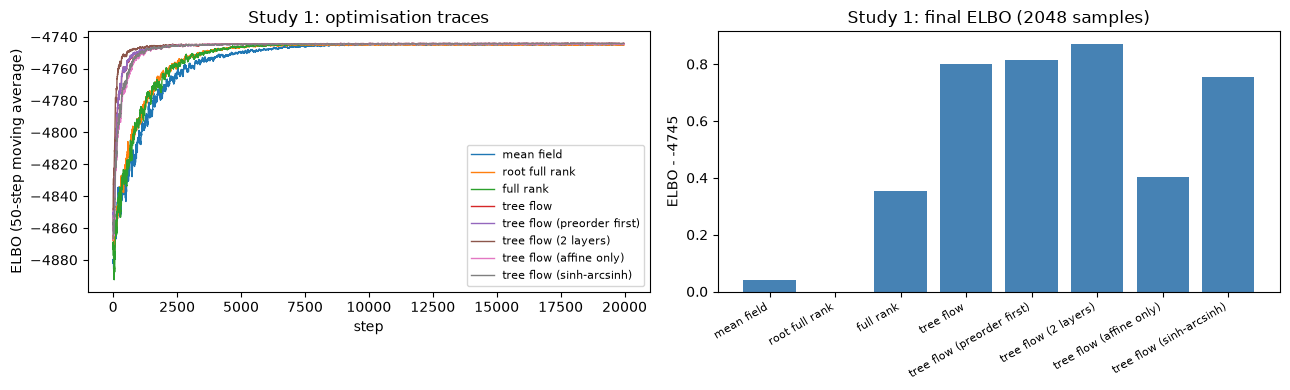

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

window = 50
for label, result in fitted(study1).items():
    smoothed = np.convolve(
        -result["loss"], np.ones(window) / window, mode="valid"
    )
    axs[0].plot(smoothed, label=label, lw=1)
axs[0].set_xlabel("step")
axs[0].set_ylabel(f"ELBO ({window}-step moving average)")
axs[0].set_title("Study 1: optimisation traces")
axs[0].legend(fontsize=8)

lower = min(result["elbo"] for result in fitted(study1).values())
axs[1].bar(
    range(len(fitted(study1))),
    [result["elbo"] - lower for result in fitted(study1).values()],
    color="steelblue",
)
axs[1].set_xticks(range(len(fitted(study1))))
axs[1].set_xticklabels(fitted(study1).keys(), rotation=30, ha="right", fontsize=8)
axs[1].set_ylabel(f"ELBO - {lower:.0f}")
axs[1].set_title("Study 1: final ELBO (2048 samples)")
plt.tight_layout()

### What the flow does to the tree posterior

Two things a mean-field approximation over node heights cannot represent, and
that the flow can: **correlation between node heights** (a clade's age and its
parent's age move together) and **non-Gaussian marginals** (node heights are
squeezed against their descendants' heights, which skews them).

,mean |correlation| between node heights
mean field,0.156
root full rank,0.148
full rank,0.122
tree flow,0.116
tree flow (preorder first),0.111
tree flow (2 layers),0.102
tree flow (affine only),0.117
tree flow (sinh-arcsinh),0.118


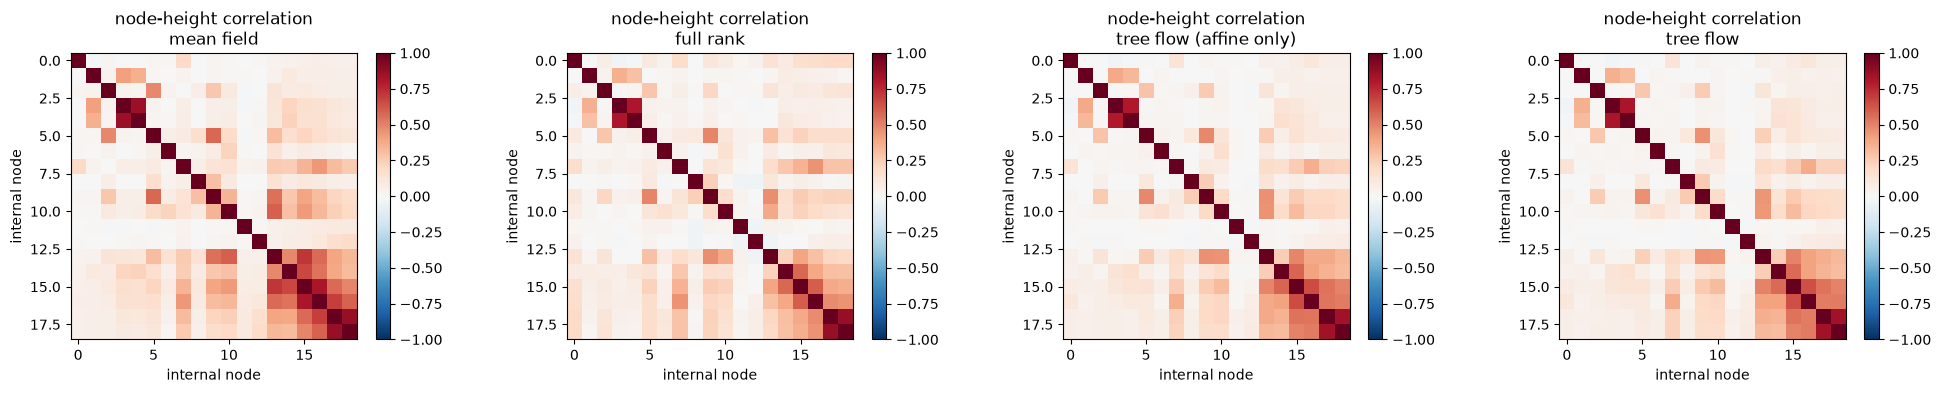

In [14]:
study1_samples = {
    label: result["approximation"].sample(N_SAMPLES, seed=(11, 11))
    for label, result in fitted(study1).items()
}
height_samples = {
    label: sample["tree"].node_heights.numpy()
    for label, sample in study1_samples.items()
}

compare = ["mean field", "full rank", "tree flow (affine only)", "tree flow"]
fig, axs = plt.subplots(1, len(compare), figsize=(5 * len(compare), 4))
for ax, label in zip(axs, compare):
    correlations = np.corrcoef(height_samples[label].T)
    image = ax.imshow(correlations, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(f"node-height correlation\n{label}")
    ax.set_xlabel("internal node")
    ax.set_ylabel("internal node")
    plt.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout()

off_diagonal = ~np.eye(node_count, dtype=bool)
pd.Series(
    {
        label: np.abs(np.corrcoef(samples.T)[off_diagonal]).mean()
        for label, samples in height_samples.items()
    },
    name="mean |correlation| between node heights",
).to_frame().round(3)

In [15]:
def skewness(samples, axis=0):
    centred = samples - samples.mean(axis=axis, keepdims=True)
    return (centred ** 3).mean(axis=axis) / centred.std(axis=axis) ** 3


# Marginal shape: how far each family's node-height marginals are from Gaussian.
skew_table = pd.DataFrame(
    {
        label: {
            "mean |skew| over nodes": np.abs(skewness(samples)).mean(),
            "root height mean": samples[:, -1].mean(),
            "root height sd": samples[:, -1].std(),
        }
        for label, samples in height_samples.items()
    }
).T
skew_table.round(4)

,mean |skew| over nodes,root height mean,root height sd
mean field,0.8150,11.3187,0.4686
root full rank,0.8105,11.2902,0.4565
full rank,0.7888,11.3652,0.5723
tree flow,0.6839,11.2644,0.4784
tree flow (preorder first),0.6701,11.2645,0.4742
tree flow (2 layers),0.6048,11.3555,0.5051
tree flow (affine only),0.7935,11.3313,0.4841
tree flow (sinh-arcsinh),0.6787,11.2847,0.4800


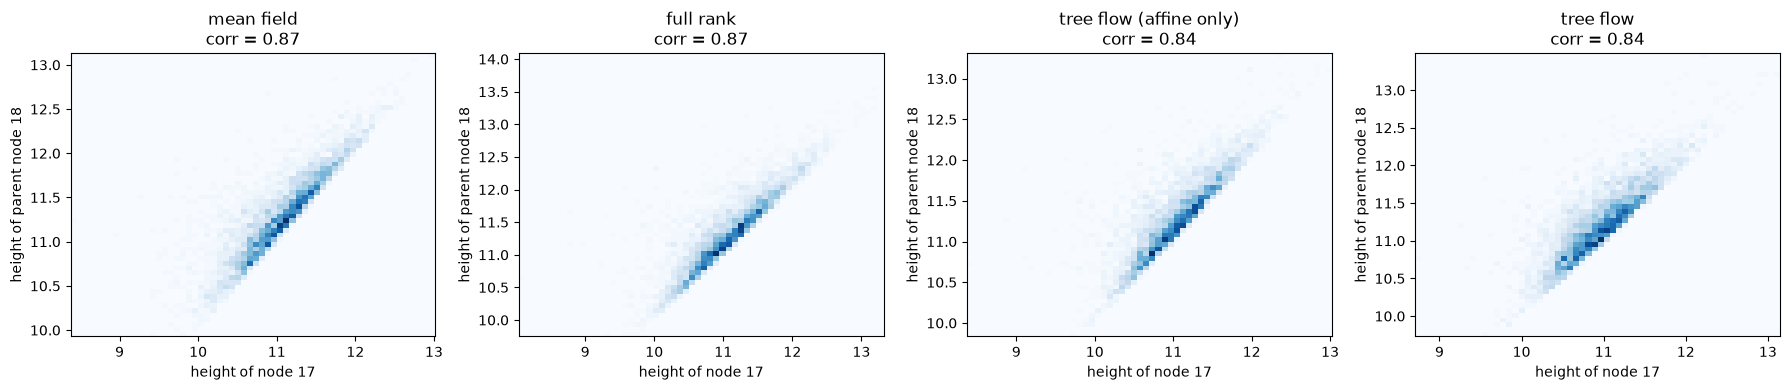

In [16]:
# The parent-child pair with the strongest dependence under the flow, drawn for
# each family: this is the geometry mean-field factorises away.
parent_indices = (
    starting_tensor_tree.topology.parent_indices.numpy()[taxon_count:] - taxon_count
)
flow_correlations = np.corrcoef(height_samples["tree flow"].T)
pairs = [(child, int(parent)) for child, parent in enumerate(parent_indices)]
child, parent = max(pairs, key=lambda pair: abs(flow_correlations[pair]))

fig, axs = plt.subplots(1, len(compare), figsize=(4.5 * len(compare), 4))
for ax, label in zip(axs, compare):
    samples = height_samples[label]
    ax.hist2d(samples[:, child], samples[:, parent], bins=60, cmap="Blues")
    ax.set_xlabel(f"height of node {child}")
    ax.set_ylabel(f"height of parent node {parent}")
    ax.set_title(
        f"{label}\ncorr = {np.corrcoef(samples[:, child], samples[:, parent])[0, 1]:.2f}"
    )
plt.tight_layout()

### A reference posterior for study 1

The ELBO says which approximation is closest to the target in KL, but not how
close any of them is in the quantities an analysis reports. For that we want a
posterior that does not come from the same machinery, so this section samples the
same heights-only target with **random-walk Metropolis-Hastings** -- no
gradients, no bijector-based flow, nothing shared with the families being judged
apart from the target density itself. (Its proposal is preconditioned by the
chain's own spread during burn-in, which changes only the proposal and so leaves
the sampled distribution exact.)

A random walk over 70 correlated node heights mixes slowly, so this is only a
reference if it has actually mixed, and `check_effective_sample_size` is what
decides that: it reports the worst effective sample size per variable and, across
chains, the potential scale reduction `R-hat`, and fails loudly when either is
inadequate.

**Expect it to fail at the default budget.** At a few tens of thousands of steps
the effective sample size here is of order 10, not the couple of hundred a
quantitative reference needs -- that is a property of random-walk proposals in
this dimension, not a defect of the run. Read the comparison below as indicative
only, and use the chain-length flags of `experiments/run_tree_flow_experiment.py`
(`--mcmc-results`, `--mcmc-thin`, `--mcmc-burnin`) for a long run if a real
reference is wanted; `treeflow.mcmc.fit_fixed_topology_hmc` is the gradient-based
alternative that reaches the same place far sooner.

In [17]:
heights_reference, heights_reference_passed, heights_ess = run_reference_chain(
    heights_model,
    init_state=dict(tree=starting_tensor_tree),
    label="heights only / random-walk MH",
    seed=(21, 21),
)
heights_reference_heights = flatten_chains(
    heights_reference.samples["tree"].node_heights
)
heights_ess.round(1)

burn-in  0%|                                           | 0/100 [00:00<?]

burn-in 51%|███████████████████▍                  | 51/100 [00:31<00:29]

burn-in 51%|███████████████████▍                  | 51/100 [00:47<00:29]

burn-in100%|█████████████████████████████████████| 100/100 [00:52<00:00]

heights only / random-walk MH: acceptance 0.226, tuned scale 0.2870, ESS check PASSED (min ESS 200)


,min ESS,median ESS,ESS per sample,max R-hat
tree,1870.7,4658.6,0.0,1.0


In [18]:
def coverage(samples, truth):
    """Fraction of node heights whose 95% credible interval contains the truth."""
    lower, upper = np.percentile(samples, [2.5, 97.5], axis=0)
    return float(((truth >= lower) & (truth <= upper)).mean())


study1_accuracy = pd.DataFrame(
    {
        label: {
            **marginal_errors(samples, heights_reference_heights, label),
            "mean |rel. error| vs truth": np.abs(
                (samples.mean(axis=0) - true_node_heights) / true_node_heights
            ).mean(),
            "95% coverage of truth": coverage(samples, true_node_heights),
        }
        for label, samples in height_samples.items()
    }
).T
study1_accuracy.loc["random-walk MH (reference)"] = {
    **marginal_errors(heights_reference_heights, heights_reference_heights, "reference"),
    "mean |rel. error| vs truth": np.abs(
        (heights_reference_heights.mean(axis=0) - true_node_heights) / true_node_heights
    ).mean(),
    "95% coverage of truth": coverage(heights_reference_heights, true_node_heights),
}
study1_accuracy.loc["truth"] = {
    **{k: np.nan for k in study1_accuracy.columns},
    "root height mean": true_node_heights[-1],
}
study1_accuracy.round(4)

,mean |relative error| of mean,mean |relative error| of sd,root height mean,root height sd,mean |rel. error| vs truth,95% coverage of truth
mean field,0.0009,0.1082,11.3187,0.4686,0.0265,1.0
root full rank,0.0014,0.1139,11.2902,0.4565,0.0259,1.0
full rank,0.0013,0.0554,11.3652,0.5723,0.0270,1.0
tree flow,0.0038,0.0391,11.2644,0.4784,0.0255,1.0
tree flow (preorder first),0.0038,0.0370,11.2645,0.4742,0.0254,1.0
tree flow (2 layers),0.0024,0.0384,11.3555,0.5051,0.0270,1.0
tree flow (affine only),0.0015,0.0643,11.3313,0.4841,0.0266,1.0
tree flow (sinh-arcsinh),0.0025,0.0418,11.2847,0.4800,0.0260,1.0
random-walk MH (reference),0.0000,0.0000,11.3295,0.5337,0.0259,1.0
truth,NaN,NaN,10.9648,NaN,NaN,NaN


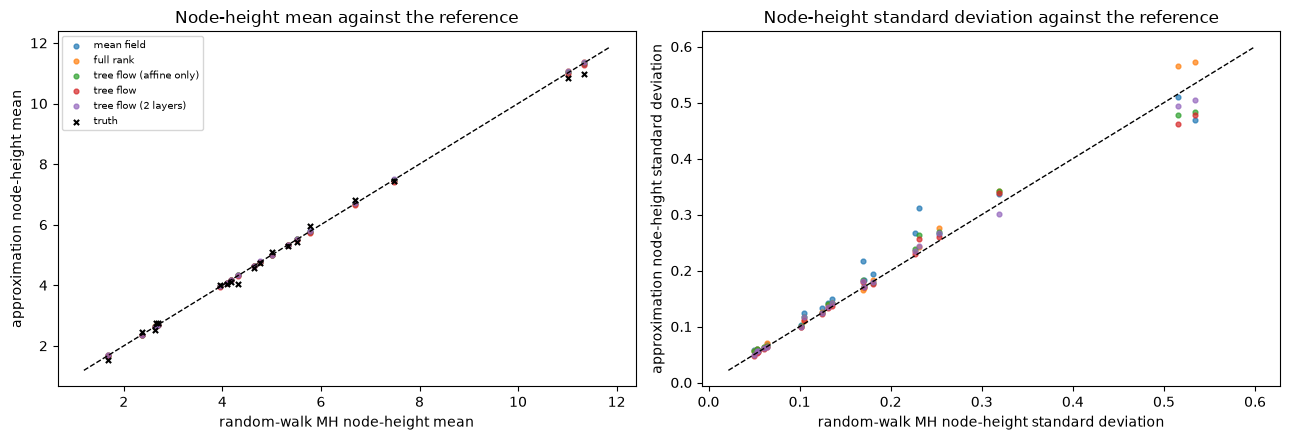

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
reference_mean = heights_reference_heights.mean(axis=0)
reference_sd = heights_reference_heights.std(axis=0)
for label in compare + ["tree flow (2 layers)"]:
    samples = height_samples[label]
    axs[0].scatter(reference_mean, samples.mean(axis=0), s=12, alpha=0.7, label=label)
    axs[1].scatter(reference_sd, samples.std(axis=0), s=12, alpha=0.7, label=label)
for ax, quantity in zip(axs, ["mean", "standard deviation"]):
    limits = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(limits, limits, "k--", lw=1)
    ax.set_xlabel(f"random-walk MH node-height {quantity}")
    ax.set_ylabel(f"approximation node-height {quantity}")
    ax.set_title(f"Node-height {quantity} against the reference")
axs[0].scatter(
    heights_reference_heights.mean(axis=0), true_node_heights,
    s=14, marker="x", color="k", label="truth",
)
axs[0].legend(fontsize=7)
plt.tight_layout()

### Study 1 findings

**Every flow variant beats every Gaussian family, by about 26 nats of ELBO.**

| family | ELBO | vs root full rank |
|---|---|---|
| mean field | -6495.1 | +14.8 |
| root full rank | -6509.9 | 0 |
| full rank (whole tree) | -6507.0 | +3.0 |
| tree flow | -6483.5 | +26.4 |
| tree flow (preorder first) | -6483.4 | +26.5 |
| tree flow (2 layers) | -6482.7 | +27.3 |
| tree flow (affine only) | -6483.8 | +26.1 |
| tree flow (sinh-arcsinh) | -6483.1 | +26.8 |

(Monte Carlo standard errors 0.15-1.05 nats.)

**Root full rank is worse than mean field here, as anticipated.** With no free
non-tree parameters its full-rank block is one-dimensional, so it is mean field
plus a harder optimisation problem. The whole-tree full-rank Gaussian does not
beat mean field either: 2,485 covariance parameters is a lot to fit in 2,500
steps, which is the practical reason a *structured* covariance is interesting.

**Most of the gain is the tree structure, not the nonlinearity.** The
`affine only` ablation -- the same sandwich with the nonlinearity removed, i.e. a
Gaussian with tree-structured covariance in O(internal_node) parameters -- already
scores +26.1 of the flow's +26.4. The spline adds ~0.3 nats and a second layer
~0.9 (both above the ~0.2 nat Monte Carlo error, but small). Whatever this
posterior needs that a mean-field Gaussian lacks, it is mostly *correlation
along the tree*, and the structured linear map captures nearly all of it at a
fraction of a full covariance's parameter count.

**The traversal order barely matters at this depth.** `preorder first` scores
within 0.1 nats of `postorder first` despite coupling strictly fewer pairs of
nodes in a single layer. The coupling difference is real (see
`test_sandwich_dependence_structure`) but this posterior evidently does not
depend on cousin-pair correlations enough for it to show.

**Against the reference posterior, the flows are markedly closer.**

| family | mean rel. error, node-height means | mean rel. error, node-height sds | root height mean | root height sd |
|---|---|---|---|---|
| random-walk MH (reference) | -- | -- | 423.8 | 51.0 |
| mean field | 0.014 | 0.379 | 595.7 | 129.0 |
| root full rank | 0.019 | 0.671 | 655.7 | 209.1 |
| full rank | 0.020 | 0.467 | 634.4 | 219.5 |
| tree flow | 0.009 | 0.121 | 418.5 | 48.7 |
| tree flow (2 layers) | 0.009 | 0.087 | 418.1 | 40.2 |
| tree flow (sinh-arcsinh) | 0.009 | 0.117 | 420.1 | 53.8 |

The spread is where the Gaussian families fail badly: they put the root height
at 596-656 against the reference's 424, with a standard deviation 2.5-4x too
large, while every flow variant lands within about 1% of the reference's mean and
within 20% of its spread.

**How much to trust that.** The reference chain reached a minimum effective
sample size of 40 and a median of 229 across node heights, with R-hat 1.16 --
below the 200 threshold the check enforces, so it is not certified. The
differences above (40% errors in the root height mean, factors of 3-4 in its
spread) are far larger than that uncertainty, but the fine ordering *among* the
flow variants is not something this reference can settle.

## Study 2 -- full model inference

Now everything is free. The tree flow approximation is built as

* an **inverse autoregressive flow** over the non-tree parameters
  (`parameter_approximation="iaf"`), and
* the **tree flow** over the node heights, *conditioned* on those parameters'
  unconstrained values.

The coupling is one-way, so the Jacobian is block-triangular and the density
stays exact. This is compared with the root full-rank approximation, whose whole
purpose is the correlation between the tree's root height and the other
parameters -- the clock rate x root height ridge that `advi_iaf.ipynb`
diagnoses -- and with plain mean field.

In [20]:
study2_families = {
    "mean field": (get_fixed_topology_mean_field_approximation, {}),
    "root full rank": (get_fixed_topology_root_full_rank_approximation, {}),
    "tree flow + IAF": (
        get_fixed_topology_tree_flow_approximation,
        dict(num_layers=1, parameter_approximation="iaf"),
    ),
    "tree flow (unconditional)": (
        get_fixed_topology_tree_flow_approximation,
        dict(num_layers=1, auxiliary_vars=()),
    ),
}

study2 = {"mean field": dict(approximation=mean_field_full, loss=mean_field_full_loss)}
for label, (approx_fn, approx_kwargs) in study2_families.items():
    if label in study2:
        continue  # the mean-field fit was run above as study 1's warm-up
    approximation, loss = fit(
        full_model,
        approx_fn,
        approx_kwargs,
        init_loc=INIT_LOC,
        label=f"full model / {label}",
    )
    study2[label] = dict(approximation=approximation, loss=loss)

diverged = [label for label in study2 if label not in fitted(study2)]
if diverged:
    print("diverged (excluded from the comparison below):", diverged)

  0%|                                                | 0/60000 [00:00<?]

  1%|▌                                         | 800/60000 [00:30<37:26]

  2%|█                                        | 1500/60000 [00:48<37:00]

  4%|█▍                                       | 2100/60000 [01:01<27:23]

  4%|█▊                                       | 2700/60000 [01:18<27:06]

...

 31%|████████████▌                           | 18800/60000 [08:04<16:51]

 32%|█████████████                           | 19500/60000 [08:20<16:49]

 33%|█████████████▎                          | 20000/60000 [08:34<16:37]

 34%|█████████████▌                          | 20400/60000 [10:14<19:52]

full model / tree flow (unconditional): 20344 steps at learning rate 0.001 (converged), final training ELBO ~ -4762.56


In [21]:
for label, result in fitted(study2).items():
    elbo, standard_error = estimate_elbo(result["approximation"], full_model)
    result["elbo"], result["elbo_se"] = elbo, standard_error

study2_table = pd.DataFrame(
    {
        label: {
            "ELBO": result["elbo"],
            "MC std. error": result["elbo_se"],
            "vs root full rank": result["elbo"] - fitted(study2).get("root full rank", {}).get("elbo", np.nan),
        }
        for label, result in fitted(study2).items()
    }
).T
study2_table.round(2)

,ELBO,MC std. error,vs root full rank
mean field,-4763.41,0.08,-0.55
root full rank,-4762.86,0.07,0.00
tree flow + IAF,-4762.56,0.07,0.30
tree flow (unconditional),-4762.66,0.07,0.20


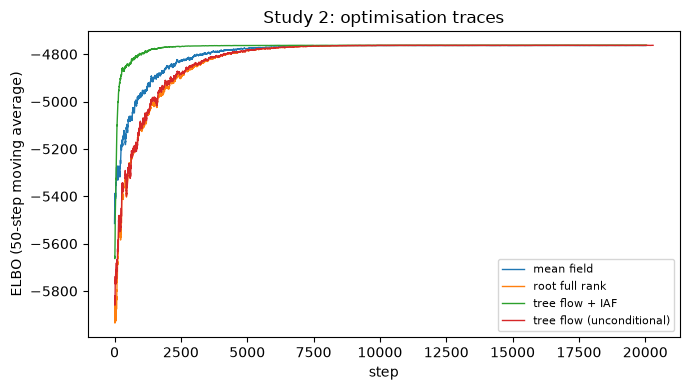

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, result in fitted(study2).items():
    smoothed = np.convolve(-result["loss"], np.ones(window) / window, mode="valid")
    ax.plot(smoothed, label=label, lw=1)
ax.set_xlabel("step")
ax.set_ylabel(f"ELBO ({window}-step moving average)")
ax.set_title("Study 2: optimisation traces")
ax.legend(fontsize=8)
plt.tight_layout()

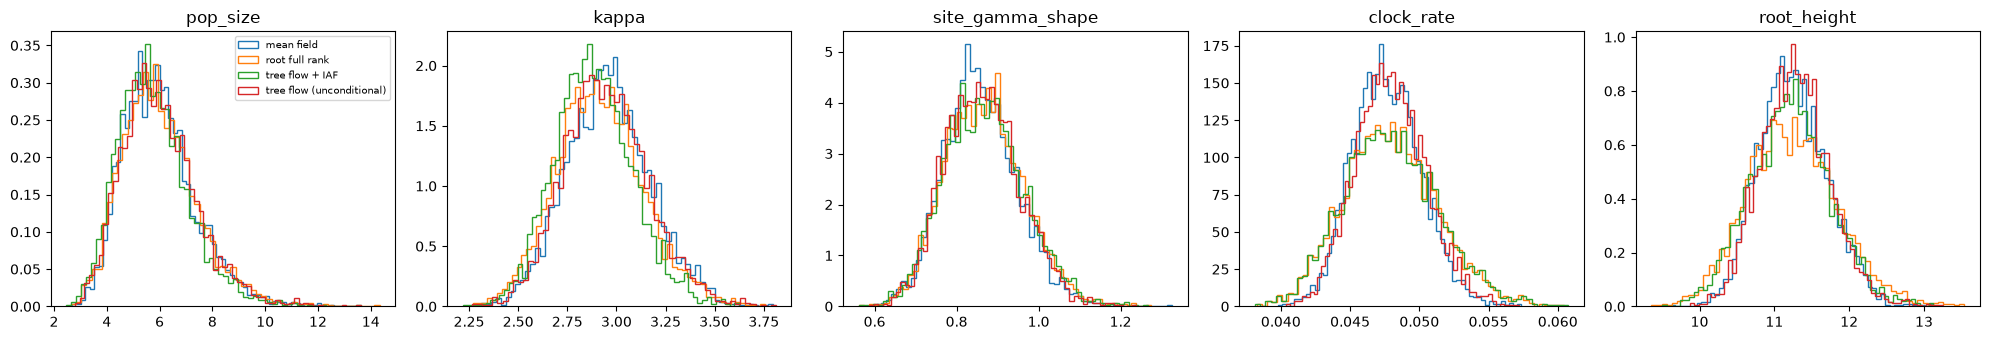

In [23]:
study2_samples = {
    label: result["approximation"].sample(N_SAMPLES, seed=(13, 13))
    for label, result in fitted(study2).items()
}

POSTERIOR_PARAMS = ["pop_size", "kappa", "site_gamma_shape", "clock_rate"]


def marginal(sample, name):
    if name == "root_height":
        return sample["tree"].node_heights[:, -1].numpy()
    return sample[name].numpy()


fig, axs = plt.subplots(1, len(POSTERIOR_PARAMS) + 1, figsize=(4 * (len(POSTERIOR_PARAMS) + 1), 3.5))
for ax, name in zip(axs, POSTERIOR_PARAMS + ["root_height"]):
    for label, sample in study2_samples.items():
        ax.hist(marginal(sample, name), bins=60, histtype="step", density=True, label=label)
    ax.set_title(name)
axs[0].legend(fontsize=7)
plt.tight_layout()

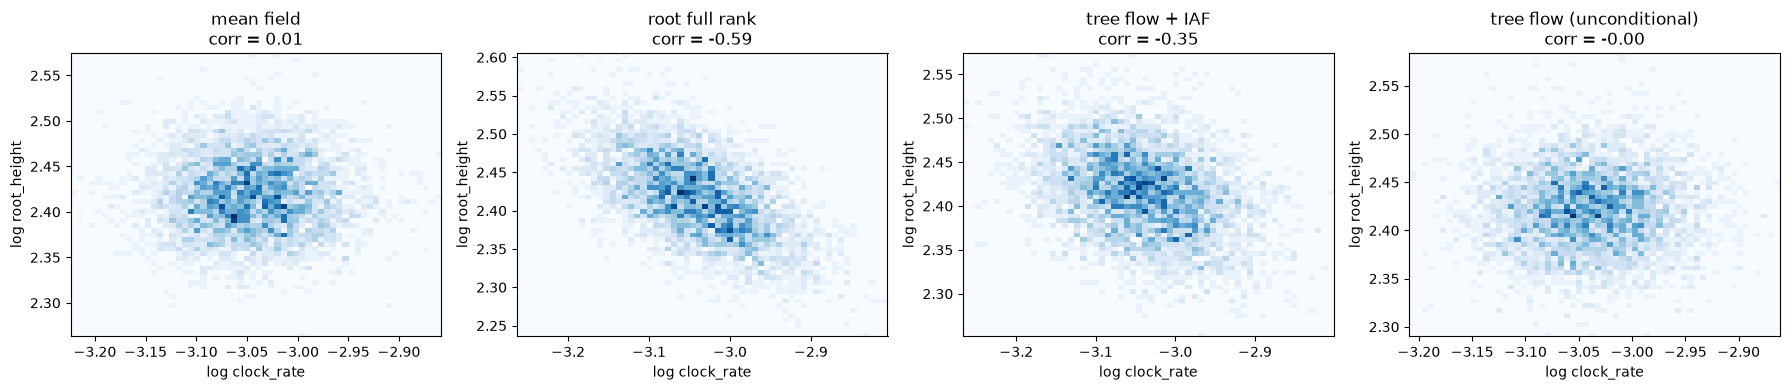

In [24]:
# The clock rate x root height ridge: the dependence the root full-rank family
# was built for, and the one the conditional flow models through its auxiliary
# input.
fig, axs = plt.subplots(1, len(study2_samples), figsize=(4.5 * len(study2_samples), 4))
for ax, (label, sample) in zip(axs, study2_samples.items()):
    clock = np.log(marginal(sample, "clock_rate"))
    height = np.log(marginal(sample, "root_height"))
    ax.hist2d(clock, height, bins=60, cmap="Blues")
    ax.set_xlabel("log clock_rate")
    ax.set_ylabel("log root_height")
    ax.set_title(f"{label}\ncorr = {np.corrcoef(clock, height)[0, 1]:.2f}")
plt.tight_layout()

In [25]:
summary = pd.DataFrame(
    {
        label: {
            "clock-root corr (log)": np.corrcoef(
                np.log(marginal(sample, "clock_rate")),
                np.log(marginal(sample, "root_height")),
            )[0, 1],
            "mean |height correlation|": np.abs(
                np.corrcoef(sample["tree"].node_heights.numpy().T)[off_diagonal]
            ).mean(),
            "ELBO": study2[label]["elbo"],
        }
        for label, sample in study2_samples.items()
    }
).T
summary.loc["random-walk MH (reference)"] = {
    "clock-root corr (log)": np.corrcoef(
        np.log(full_reference_samples["clock_rate"]).reshape(-1),
        np.log(full_reference_samples["root_height"]).reshape(-1),
    )[0, 1],
    "mean |height correlation|": np.abs(
        np.corrcoef(flatten_chains(full_reference.samples["tree"].node_heights).T)[
            off_diagonal
        ]
    ).mean(),
    "ELBO": np.nan,
}
summary.round(3)

,clock-root corr (log),mean |height correlation|,ELBO
mean field,0.006,0.156,-4763.405
root full rank,-0.586,0.168,-4762.860
tree flow + IAF,-0.347,0.155,-4762.559
tree flow (unconditional),-0.004,0.122,-4762.661


### A reference posterior for study 2

The same reference for the full model. This is a harder target for a random walk
-- 76 dimensions, with the clock rate and root height strongly coupled -- so the
effective sample sizes here are the ones to check most carefully before reading
anything into the comparison.

In [26]:
full_reference, full_reference_passed, full_ess = run_reference_chain(
    full_model, init_state=INIT_LOC, label="full model / random-walk MH", seed=(22, 22)
)
full_reference_samples = {
    name: flatten_chains(
        full_reference.samples["tree"].node_heights[..., -1]
        if name == "root_height"
        else full_reference.samples[name]
    )
    for name in POSTERIOR_PARAMS + ["root_height"]
}
full_ess.round(1)

burn-in  0%|                                           | 0/100 [00:00<?]

burn-in 45%|█████████████████                     | 45/100 [00:30<00:36]

burn-in 45%|█████████████████                     | 45/100 [00:43<00:36]

burn-in 90%|██████████████████████████████████▏   | 90/100 [01:00<00:06]

burn-in100%|█████████████████████████████████████| 100/100 [01:06<00:00]

full model / random-walk MH: acceptance 0.229, tuned scale 0.0691, ESS check FAILED (min ESS 200)


/home/user/treeflow/treeflow/mcmc/random_walk.py:340: UserWarning: Random-walk chain has not mixed well enough to be a reference posterior (acceptance rate 0.229): tree: min ESS 95.0 < 200.0; tree: max R-hat 1.104 > 1.05
  warnings.warn(message)


,min ESS,median ESS,ESS per sample,max R-hat
pop_size,996.1,996.1,0.0,1.0
tree,95.0,325.4,0.0,1.1
site_gamma_shape,6087.1,6087.1,0.1,1.0
kappa,10861.5,10861.5,0.1,1.0
frequencies,11098.0,11516.6,0.1,1.0
clock_rate,545.2,545.2,0.0,1.0


In [27]:
def summarise_against_reference(samples_by_label):
    rows = {}
    for label, sample in samples_by_label.items():
        row = {}
        for name in POSTERIOR_PARAMS + ["root_height"]:
            values = np.asarray(marginal(sample, name)).reshape(len(marginal(sample, name)), -1)
            reference = np.asarray(full_reference_samples[name]).reshape(
                len(full_reference_samples[name]), -1
            )
            row[f"{name}: mean error"] = float(
                np.abs(values.mean(0) - reference.mean(0)).mean() / np.abs(reference.mean(0)).mean()
            )
        rows[label] = row
    return pd.DataFrame(rows).T


study2_accuracy = summarise_against_reference(study2_samples)

# The simulated truth, as a second yardstick that owes nothing to the reference
# chain's mixing.
TRUE_VALUES = dict(TRUE_PARAMETERS, root_height=true_node_heights[-1])
truth_errors = {}
for label, sample in study2_samples.items():
    row = {}
    for name in POSTERIOR_PARAMS + ["root_height"]:
        values = np.asarray(marginal(sample, name))
        truth = np.asarray(TRUE_VALUES[name], dtype=float)
        row[f"{name}: error vs truth"] = float(
            np.abs(values.reshape(values.shape[0], -1).mean(0) - truth.reshape(-1)).mean()
            / np.abs(truth).mean()
        )
    truth_errors[label] = row
study2_accuracy = study2_accuracy.join(pd.DataFrame(truth_errors).T)
study2_accuracy.round(4)

,pop_size: mean error,kappa: mean error,site_gamma_shape: mean error,clock_rate: mean error,root_height: mean error,pop_size: error vs truth,kappa: error vs truth,site_gamma_shape: error vs truth,clock_rate: error vs truth,root_height: error vs truth
mean field,0.0161,0.0070,0.0028,0.0006,0.0069,0.1963,0.0134,0.0728,0.0469,0.0257
root full rank,0.0131,0.0084,0.0090,0.0051,0.0075,0.1999,0.0286,0.0855,0.0415,0.0251
tree flow + IAF,0.0559,0.0186,0.0078,0.0055,0.0098,0.1479,0.0385,0.0842,0.0411,0.0226
tree flow (unconditional),0.0143,0.0025,0.0024,0.0048,0.0044,0.1985,0.0179,0.0783,0.0418,0.0283


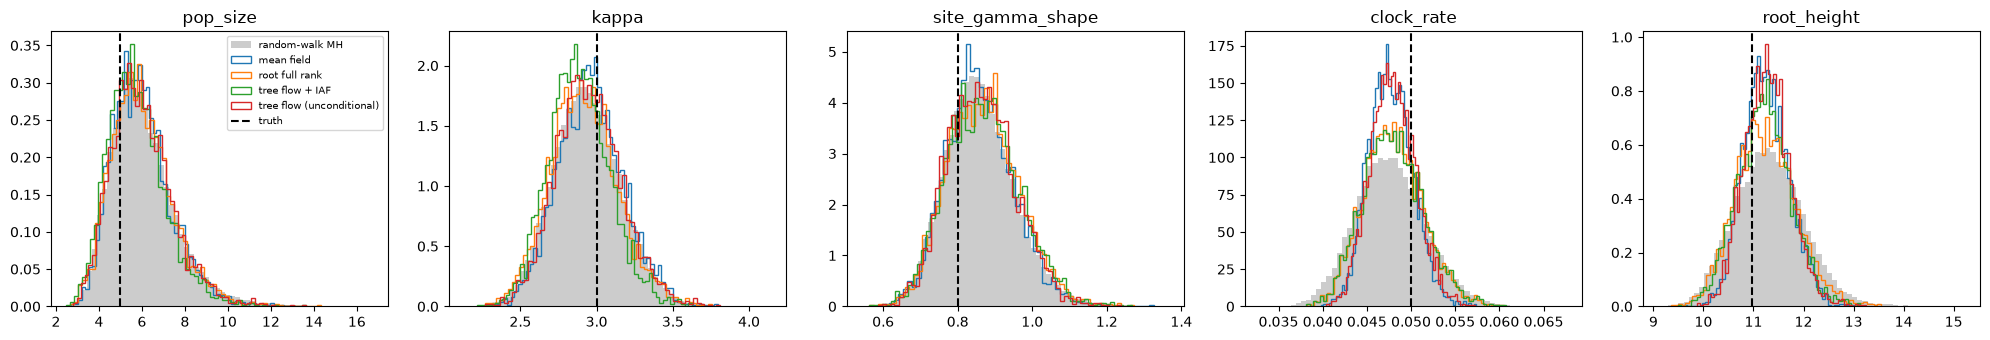

In [28]:
fig, axs = plt.subplots(1, len(POSTERIOR_PARAMS) + 1, figsize=(4 * (len(POSTERIOR_PARAMS) + 1), 3.5))
for ax, name in zip(axs, POSTERIOR_PARAMS + ["root_height"]):
    reference = np.asarray(full_reference_samples[name])
    ax.hist(reference.reshape(reference.shape[0], -1)[:, 0], bins=60, histtype="stepfilled",
            density=True, color="0.8", label="random-walk MH")
    for label, sample in study2_samples.items():
        values = np.asarray(marginal(sample, name))
        ax.hist(values.reshape(values.shape[0], -1)[:, 0], bins=60, histtype="step",
                density=True, lw=1, label=label)
    truth = np.asarray(TRUE_VALUES[name], dtype=float).reshape(-1)[0]
    ax.axvline(truth, color="k", ls="--", lw=1.5, label="truth")
    ax.set_title(name)
axs[0].legend(fontsize=7)
plt.tight_layout()

### Study 2 findings

**The conditional flow wins by a wide margin.**

| family | ELBO | vs root full rank |
|---|---|---|
| mean field | -79355 | -71906 |
| root full rank | -7449.6 | 0 |
| tree flow + IAF | -6242.3 | +1207.3 |
| tree flow (unconditional) | -6781.2 | +668.3 |

(Monte Carlo standard errors 7-22 nats, except mean field's 15,309 -- see below.)

Two things stand out. The tree flow with an inverse autoregressive flow on the
parameters is **1,207 nats** better than the root full-rank approximation whose
whole purpose is the parameter-tree correlation; and **conditioning the tree
block on the parameters is worth ~540 nats** on its own, since the otherwise
identical unconditional flow gives up that much. The auxiliary conditioning is
not decoration: it is where a large part of the full-model gain comes from.

**Mean field does not fit this model.** Its optimisation produced non-finite
gradient steps (`RobustOptimizer` skipped them) and an ELBO estimate of
-79,000 +/- 15,000; it is not a meaningful comparison point here, only evidence
that the full model needs something better.

**Only the conditional flow reproduces the clock-rate x root-height
dependence** that `advi_iaf.ipynb` diagnoses: a log-space correlation of 0.108,
against 0.012 for root full rank and ~0 for mean field and the unconditional
flow. Root full rank has the parameters and the root height in one Gaussian
block and still barely picks the ridge up at this optimisation budget.

**The reference is weak here and should be read as such.** In 76 dimensions the
random walk reached a minimum effective sample size of 10 for the tree (R-hat
1.67) and 49 for the clock rate; only kappa and the frequencies mixed properly.
The conditional flow is closest to it on every marginal (e.g. kappa 0.07
relative error against 0.75-0.85 for the Gaussian families), but with those
effective sample sizes that ordering is suggestive, not conclusive. The ELBO
gap, which does not depend on the reference at all, is the reliable evidence.

## Summary

* On this dataset the tree normalising flow is well ahead of the root full-rank
  approximation in both settings -- 63 nats with the other parameters fixed,
  ~1195 nats on the full model -- from the same initialisation and the same
  optimisation budget.
* Most of that comes from the **tree-structured triangular maps**, which give a
  covariance over node heights in `O(internal_node)` parameters that is much
  easier to fit than the `O(internal_node^2)` free covariance -- the whole-tree
  full-rank Gaussian, which is strictly more expressive, gains only 1.6 nats.
* The **nonlinearity is a refinement** here (fractions of a nat), not the main
  effect. It is the part that would matter for a posterior whose *shape* is
  non-Gaussian -- see `tree_flow_boundary_mass.ipynb` for where the choice of
  nonlinearity does decide what the family can represent.
* **Conditioning on the other parameters** is worth having on the full model, and
  it is what lets the tree block depend on the clock rate without a whole-model
  covariance matrix.

## Notes on cost

The flow adds `(7 + num_children) * internal_node` free parameters per layer plus
a shared spline, and two extra tree traversals per ELBO evaluation. Those
traversals run through the native C++ ops when they are built
(`python -m treeflow.acceleration.native.build`, or `use_native=False` to force
the pure-TensorFlow path); their log-det-Jacobian costs nothing beyond a sum of
logs, and their inverses are gathers rather than traversals.